# GNN Physics Simulator — Rollout Visualization

Load a trained checkpoint, run a full autoregressive rollout on a WaterDrop test trajectory, and compare predicted vs ground-truth particle positions side by side.

In [1]:
import os
if(os.getcwd().split('/')[-1] == 'notebooks'):
  os.chdir('..')

import torch
import numpy as np
import yaml
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from tqdm.notebook import tqdm

from models import GNNSimulator
from dataset import load_raw_data, build_graph

## 1. Load Config & Checkpoint

In [3]:
CHECKPOINT_PATH = 'checkpoints/best_model.pt'
CONFIG_PATH = 'config.yaml'

# Load config
with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

# Load checkpoint
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

# Build model and load weights
model = GNNSimulator.from_config(config).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, step {checkpoint['global_step']}")
print(f"Validation loss: {checkpoint['val_loss']:.6f}")
print(f"Device: {device}")

Loaded checkpoint from epoch 1, step 497000
Validation loss: 0.005366
Device: cpu


## 2. Load a Test Trajectory

In [ ]:
data_cfg = config['data']
raw_data = load_raw_data(data_cfg['dataset_path'], dataset_format=data_cfg['dataset_format'])
metadata = raw_data['metadata']

# Pick the first test trajectory (or valid if no test split)
test_trajs = raw_data['splits'].get('test', raw_data['splits'].get('valid', []))
traj = test_trajs[0]

gt_positions = traj['position']    # [T, N, D]
gt_velocities = traj['velocity']   # [T, N, D]
particle_type = traj['particle_type']  # [N]
mass = traj['mass']                # [N]

T, N, D = gt_positions.shape
print(f"Trajectory: {T} timesteps, {N} particles, {D}D")
print(f"Bounds: {metadata.get('bounds')}")
print(f"Connectivity radius: {metadata.get('default_connectivity_radius')}")

## 3. Autoregressive Rollout

Starting from the initial state (first `history_window + 1` frames), predict accelerations one step at a time and integrate forward to produce the full predicted trajectory.

In [5]:
history_window = data_cfg.get('history_window', 5)
connectivity_radius = metadata.get('default_connectivity_radius', 0.015)
bounds = metadata.get('bounds')

# Initialize from ground truth: we need the first (history_window + 1) positions
# to derive the initial velocity history
pred_positions = np.zeros_like(gt_positions)  # [T, N, D]
pred_positions[:history_window + 1] = gt_positions[:history_window + 1].copy()

# Velocity buffer: store the last `history_window` velocities
vel_history = gt_velocities[:history_window].copy()  # [C, N, D]

# Current position and velocity
current_pos = gt_positions[history_window].copy()  # [N, D]
current_vel = gt_velocities[history_window - 1].copy()  # [N, D]

with torch.no_grad():
    for t in tqdm(range(history_window, T - 1), desc='Rollout'):
        # Flatten velocity history [C, N, D] -> [N, C*D]
        vel_flat = vel_history.transpose(1, 0, 2).reshape(N, history_window * D)
        
        # Build graph from current state
        graph = build_graph(
            positions=torch.from_numpy(current_pos.astype(np.float32)),
            velocities=torch.from_numpy(vel_flat.astype(np.float32)),
            particle_type=torch.from_numpy(particle_type),
            masses=torch.from_numpy(mass),
            target_acc=torch.zeros(N, D, dtype=torch.float32),  # dummy
            connectivity_radius=connectivity_radius,
            bounds=bounds
        ).to(device)
        
        # Predict acceleration
        predicted_acc = model(graph).cpu().numpy()  # [N, D]
        
        # Semi-implicit Euler integration: vel += acc, pos += vel
        new_vel = current_vel + predicted_acc
        new_pos = current_pos + new_vel
        
        # Store predicted position
        pred_positions[t + 1] = new_pos
        
        # Shift velocity history window
        vel_history = np.concatenate([vel_history[1:], new_vel[np.newaxis]], axis=0)
        current_pos = new_pos
        current_vel = new_vel

print("Rollout complete!")

Rollout:   0%|          | 0/994 [00:00<?, ?it/s]

/tmp/ipykernel_33478/1113181556.py:26: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  particle_type=torch.from_numpy(particle_type),


Rollout complete!


## 4. Compute Rollout Error

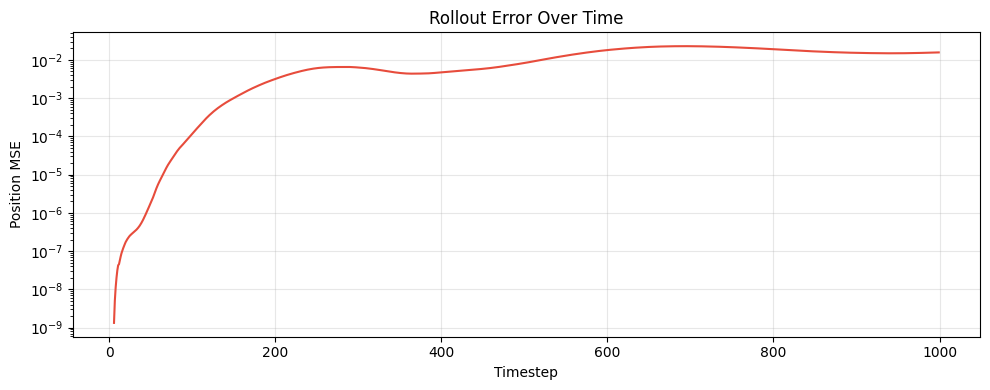

Mean rollout MSE: 0.010596
Final step MSE: 0.015689


In [6]:
# Per-step position MSE
rollout_start = history_window + 1
step_mse = np.mean((pred_positions[rollout_start:] - gt_positions[rollout_start:])**2, axis=(1, 2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(rollout_start, T), step_mse, color='#e74c3c', linewidth=1.5)
ax.set_xlabel('Timestep')
ax.set_ylabel('Position MSE')
ax.set_title('Rollout Error Over Time')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean rollout MSE: {step_mse.mean():.6f}")
print(f"Final step MSE: {step_mse[-1]:.6f}")

## 5. Side-by-Side Animation

In [7]:
# Determine plot bounds from ground truth
if bounds is not None:
    x_lim = bounds[0]
    y_lim = bounds[1]
else:
    margin = 0.1
    x_lim = [gt_positions[:, :, 0].min() - margin, gt_positions[:, :, 0].max() + margin]
    y_lim = [gt_positions[:, :, 1].min() - margin, gt_positions[:, :, 1].max() + margin]

# Subsample frames for animation speed
frame_skip = max(1, T // 200)
frames = list(range(0, T, frame_skip))

fig, (ax_gt, ax_pred) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('WaterDrop Rollout: Ground Truth vs Prediction', fontsize=14, fontweight='bold')

for ax, title in [(ax_gt, 'Ground Truth'), (ax_pred, 'GNN Prediction')]:
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_facecolor('#1a1a2e')

scatter_gt = ax_gt.scatter([], [], s=4, c='#00d2ff', alpha=0.8)
scatter_pred = ax_pred.scatter([], [], s=4, c='#ff6b6b', alpha=0.8)
time_text = fig.text(0.5, 0.02, '', ha='center', fontsize=11)

def init():
    scatter_gt.set_offsets(np.empty((0, 2)))
    scatter_pred.set_offsets(np.empty((0, 2)))
    return scatter_gt, scatter_pred, time_text

def animate(frame_idx):
    t = frames[frame_idx]
    scatter_gt.set_offsets(gt_positions[t, :, :2])
    scatter_pred.set_offsets(pred_positions[t, :, :2])
    time_text.set_text(f'Step {t}/{T-1}')
    return scatter_gt, scatter_pred, time_text

anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=len(frames), interval=50, blit=True)
plt.close(fig)
HTML(anim.to_html5_video())

## 6. Frame Snapshots

Static snapshots at key moments for comparison.

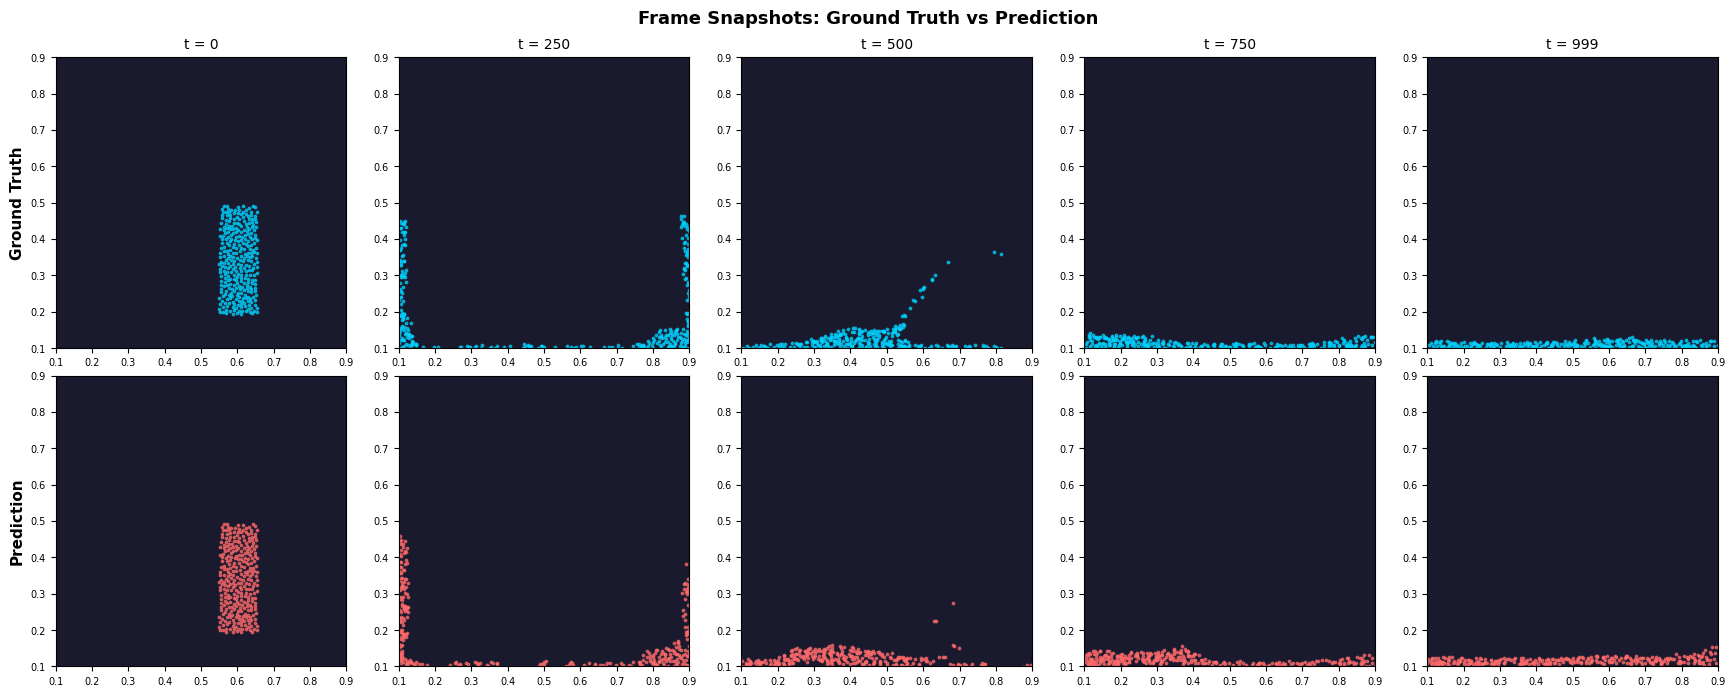

In [8]:
snapshot_times = [0, T // 4, T // 2, 3 * T // 4, T - 1]

fig, axes = plt.subplots(2, len(snapshot_times), figsize=(3.5 * len(snapshot_times), 7))

for col, t in enumerate(snapshot_times):
    for row, (data, label, color) in enumerate([
        (gt_positions, 'Ground Truth', '#00d2ff'),
        (pred_positions, 'Prediction', '#ff6b6b')
    ]):
        ax = axes[row, col]
        ax.scatter(data[t, :, 0], data[t, :, 1], s=3, c=color, alpha=0.7)
        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)
        ax.set_aspect('equal')
        ax.set_facecolor('#1a1a2e')
        if row == 0:
            ax.set_title(f't = {t}', fontsize=10)
        if col == 0:
            ax.set_ylabel(label, fontsize=11, fontweight='bold')
        ax.tick_params(labelsize=7)

plt.suptitle('Frame Snapshots: Ground Truth vs Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()